# Proyecto RappiPlus: de datos a decisiones de negocio

**Introducción**


El objetivo de este proyecto es evaluar el desempeño del servicio **RappiPlus** para apoyar **decisiones de negocio basadas en datos**.

Se trabajan con múltiples datasets del negocio:

- **rappiplus_orders_raw.csv** → información de pedidos, precios, descuentos y revenue  
- **rappiplus_catalog.csv** → costos de productos, categorías y proveedores  
- **rappiplus_marketing_spend.csv** → inversión en marketing por canal y país  
- **events / users / user_activity (SQL)** → comportamiento del usuario dentro de la plataforma  
- **experiment_checkout_ui.csv** → resultados de un experimento A/B en el checkout  

El análisis sigue una lógica clara y progresiva:

1. 🔍 Evaluar si podemos confiar en los datos (calidad de datos en Python)

2. 💰 Analizar si el negocio es rentable (revenue, costos y profit)  

3. 🛒 Entender dónde se pierden los usuarios (funnel de conversión)  

4. 🔁 Evaluar si los usuarios regresan (retención por cohortes)  

5. 🧪 Validar si los cambios generan impacto (test estadístico)  

6. 📊 Comunicar los resultados (dashboard en BI)  

A lo largo del proyecto, se transforman datos en insights para responder preguntas clave del negocio y proponer **recomendaciones accionables**.

---

## 🔹 Paso 1: Cargar y validar la calidad de los datos

---

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:** Familiarizarte con la estructura de los datasets del negocio antes de analizarlos.

**Instrucciones:**

- Importa las librerías necesarias
- Carga los archivos:
  - `rappiplus_orders_raw.csv`
  - `rappiplus_catalog.csv`
  - `rappiplus_marketing_spend.csv`
- Guarda los DataFrames en:
  - `orders`, `catalog`, `marketing`
- Explora cada dataset.

---

In [ ]:
# importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.proportion import proportions_ztest

In [ ]:
# cargar archivos
orders = pd.read_csv('https://practicum-content.s3.amazonaws.com/datasets/rappiplus_orders_raw.csv')
catalog = pd.read_csv('https://practicum-content.s3.amazonaws.com/datasets/rappiplus_catalog.csv')
marketing = pd.read_csv("https://practicum-content.s3.amazonaws.com/datasets/rappiplus_marketing_spend.csv")

In [ ]:

orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25100 entries, 0 to 25099
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id_pedido           25100 non-null  object 
 1   id_usuario          25100 non-null  object 
 2   fecha_hora_pedido   25100 non-null  object 
 3   pais                24800 non-null  object 
 4   dispositivo         25080 non-null  object 
 5   fuente_referencia   25070 non-null  object 
 6   nombre_producto     25070 non-null  object 
 7   categoria_producto  25020 non-null  object 
 8   cantidad            25050 non-null  float64
 9   precio_unitario     25050 non-null  float64
 10  monto_descuento     25050 non-null  float64
 11  monto_total         25100 non-null  float64
dtypes: float64(4), object(8)
memory usage: 2.3+ MB


In [ ]:
catalog.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   nombre_producto     7 non-null      object 
 1   categoria_producto  7 non-null      object 
 2   costo_unitario      7 non-null      float64
 3   proveedor           7 non-null      object 
dtypes: float64(1), object(3)
memory usage: 352.0+ bytes


In [ ]:
marketing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1620 entries, 0 to 1619
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   fecha       1620 non-null   object 
 1   pais        1620 non-null   object 
 2   id_campaña  1620 non-null   object 
 3   canal       1519 non-null   object 
 4   gasto       1620 non-null   float64
dtypes: float64(1), object(4)
memory usage: 63.4+ KB


---

### Revisión y calidad de datos

**🎯 Objetivo:** Detectar y corregir problemas en los datos que puedan afectar el análisis de revenue, costos y rentabilidad.

Se revisan los 3 datasets
- Validar y convertir fechas al formato correcto  
- Revisar variables numéricas (sin negativos o ceros inválidos)  
- Verificar consistencia de montos  
- Eliminar duplicados  
- Revisar variables categóricas

---

In [ ]:
orders_clean= orders.copy()

In [ ]:
orders_clean.head()

,id_pedido,id_usuario,fecha_hora_pedido,pais,dispositivo,fuente_referencia,nombre_producto,categoria_producto,cantidad,precio_unitario,monto_descuento,monto_total
0,order_0,user_6993,2025-05-22,Argentina,desktop,organic,Jacket-Winter-M,Moda,2.0,332.69,0.0,665.37
1,order_1,user_1329,2025-06-15,Mexico,desktop,paid_search,Tablet-Standard-64GB,Electronica,1.0,176.86,5.0,171.86
2,order_2,user_3194,2025-05-02,Argentina,desktop,social,Blender-XL-Red,Hogar,2.0,102.99,10.0,195.99
3,order_3,user_4510,2025-06-09,Colombia,mobile,social,Tablet-Standard-64GB,Electronica,1.0,257.87,15.0,242.87
4,order_4,user_5044,2025-03-30,Argentina,desktop,paid_search,Blender-XL-Red,Hogar,1.0,336.28,0.0,336.28


In [ ]:
orders_clean.info()
#fecha hora pedido debe de ser datetime en vez de object

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25100 entries, 0 to 25099
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id_pedido           25100 non-null  object 
 1   id_usuario          25100 non-null  object 
 2   fecha_hora_pedido   25100 non-null  object 
 3   pais                24800 non-null  object 
 4   dispositivo         25080 non-null  object 
 5   fuente_referencia   25070 non-null  object 
 6   nombre_producto     25070 non-null  object 
 7   categoria_producto  25020 non-null  object 
 8   cantidad            25050 non-null  float64
 9   precio_unitario     25050 non-null  float64
 10  monto_descuento     25050 non-null  float64
 11  monto_total         25100 non-null  float64
dtypes: float64(4), object(8)
memory usage: 2.3+ MB


In [ ]:
#corregir tipo de dato
orders_clean['fecha_hora_pedido'] = pd.to_datetime(orders_clean['fecha_hora_pedido'],errors='coerce')
#Verificar cambio
orders_clean['fecha_hora_pedido'].dtype

dtype('<M8[ns]')

In [ ]:
#revisar variables categóricas

columnas_categoricas=['pais','dispositivo','fuente_referencia','nombre_producto','categoria_producto']
for col in columnas_categoricas:
    print(orders_clean[col].value_counts())
    print()
#La columna pais tiene paises escritos de diferente forma, no se detectaron categorías inválidas

Colombia     7520
Mexico       7502
Argentina    7291
mexico        865
colombia      823
argentina     799
Name: pais, dtype: int64

desktop    12759
mobile     12321
Name: dispositivo, dtype: int64

social         8428
organic        8329
paid_search    8313
Name: fuente_referencia, dtype: int64

Vacuum-Pro-Black        4199
Blender-XL-Red          4195
Jacket-Winter-M         4192
Sneakers-Urban-42       4160
Laptop-Gaming-16GB      2794
Tablet-Standard-64GB    2780
Phone-Pro-128GB         2750
Name: nombre_producto, dtype: int64

Hogar          8385
Moda           8323
Electronica    8312
Name: categoria_producto, dtype: int64



In [ ]:
#Normalizar nombres país
orders_clean['pais'] = orders_clean['pais'].astype('string').str.strip().str.title()
orders_clean['pais'].value_counts()

Mexico       8367
Colombia     8343
Argentina    8090
Name: pais, dtype: Int64

In [ ]:
#conteo de duplicados
orders_clean.duplicated().sum()

100

In [ ]:
keys=['id_pedido']
orders_clean = orders_clean.drop_duplicates(subset=keys , keep='first').reset_index(drop=True)
#Verificar cambio
orders_clean.duplicated().sum()

0

In [ ]:
#Revisar columnas numéricas
orders_clean[['cantidad','precio_unitario','monto_descuento','monto_total']].describe()
#En cantidad, hay un valor mínimo de -2, y un valor máximo de 20,000 ambos valores inválidos, monto total, también tiene  valores negativos en mínimo

,cantidad,precio_unitario,monto_descuento,monto_total
count,24950.000000,24950.000000,24950.000000,2.500000e+04
mean,7.115110,259.374527,4.502605,2.079498e+03
std,296.869961,138.690738,5.224057,9.914760e+04
min,-2.000000,20.030000,0.000000,-4.926500e+02
25%,1.000000,138.470000,0.000000,1.806700e+02
50%,2.000000,258.795000,0.000000,3.418050e+02
75%,2.000000,380.377500,10.000000,5.185800e+02
max,20000.000000,499.960000,15.000000,8.840200e+06


In [ ]:
#Ver número de valores inválidos en cantidad
orders_clean['cantidad'].le(0).sum()

4

In [ ]:
#revisar columnas con cantidad inválida
orders_clean[orders_clean['cantidad']<=0]
#tanto cantidad como monto total tienen valores inválidos y no se pueden reconstruir la una con la otra

,id_pedido,id_usuario,fecha_hora_pedido,pais,dispositivo,fuente_referencia,nombre_producto,categoria_producto,cantidad,precio_unitario,monto_descuento,monto_total
266,order_266,user_7011,2025-03-13,<NA>,desktop,paid_search,Phone-Pro-128GB,Electronica,-2.0,101.31,10.0,-192.62
267,order_267,user_1087,2025-05-07,<NA>,desktop,social,Phone-Pro-128GB,Electronica,-1.0,43.50,5.0,-38.50
268,order_268,user_84,2025-02-19,<NA>,desktop,organic,Phone-Pro-128GB,Electronica,-1.0,497.65,5.0,-492.65
269,order_269,user_3323,2025-05-25,<NA>,desktop,paid_search,Phone-Pro-128GB,Electronica,-1.0,423.53,0.0,-423.53


In [ ]:
#Porcentaje que representan los valores inválidos
orders_clean['cantidad'].le(0).mean()

0.00016

In [ ]:
#eliminar valores inválidos
orders_clean=orders_clean[~((orders_clean['cantidad']<=0)&(orders_clean['monto_total']<=0))]
orders_clean['cantidad'].le(0).sum()

0

<AxesSubplot:>

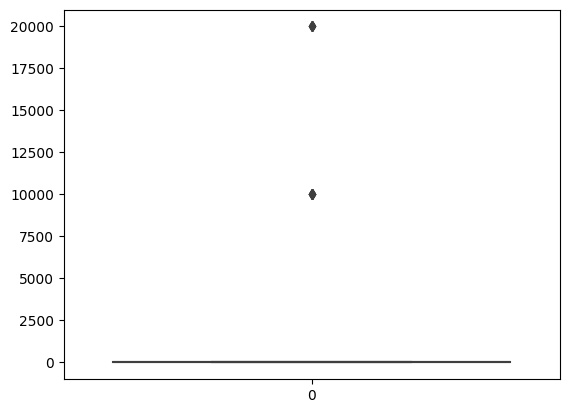

In [ ]:
#Visualizar valores atípicos
sns.boxplot(data=orders_clean['cantidad'])
#10,000 y 20,000 son valores atípicos

In [ ]:
#ver columnas con outliers
orders_clean[orders_clean['cantidad']>100]
#Estos valores atípicos se ven como un error de captura, y serán winsorizados

,id_pedido,id_usuario,fecha_hora_pedido,pais,dispositivo,fuente_referencia,nombre_producto,categoria_producto,cantidad,precio_unitario,monto_descuento,monto_total
3521,order_3521,user_5812,2025-02-03,Mexico,mobile,paid_search,Laptop-Gaming-16GB,Electronica,10000.0,43.14,0.0,431400.0
3522,order_3522,user_3575,2025-03-29,Argentina,desktop,social,Laptop-Gaming-16GB,Electronica,10000.0,280.55,0.0,2805500.0
3586,order_3586,user_3380,2025-02-03,Mexico,mobile,paid_search,Laptop-Gaming-16GB,Electronica,10000.0,490.35,0.0,4903500.0
3643,order_3643,user_4440,2025-01-07,Colombia,desktop,social,Laptop-Gaming-16GB,Electronica,10000.0,238.15,0.0,2381500.0
3656,order_3656,user_884,2025-01-01,Argentina,mobile,organic,Laptop-Gaming-16GB,Electronica,20000.0,297.66,0.0,5953200.0
3668,order_3668,user_7270,2025-06-24,Mexico,mobile,paid_search,Laptop-Gaming-16GB,Electronica,20000.0,348.31,0.0,6966200.0
3689,order_3689,user_6566,2025-06-16,Mexico,desktop,paid_search,Laptop-Gaming-16GB,Electronica,10000.0,87.69,0.0,876900.0
3722,order_3722,user_4723,2025-05-09,Argentina,mobile,paid_search,Laptop-Gaming-16GB,Electronica,20000.0,442.01,0.0,8840200.0
3726,order_3726,user_2536,2025-02-12,Colombia,desktop,social,Laptop-Gaming-16GB,Electronica,20000.0,290.85,0.0,5817000.0
3748,order_3748,user_7096,2025-02-23,Mexico,desktop,organic,Laptop-Gaming-16GB,Electronica,10000.0,336.93,0.0,3369300.0


In [ ]:
#winsorizacion outlier

lower = orders_clean['cantidad'].quantile(0.01)
upper = orders_clean['cantidad'].quantile(0.99)
orders_clean['cantidad_winsor']=np.clip(orders_clean['cantidad'],lower,upper)
#Verificar el cambio
orders_clean.loc[orders_clean['cantidad']>100, ['cantidad','cantidad_winsor']]

,cantidad,cantidad_winsor
3521,10000.0,2.0
3522,10000.0,2.0
3586,10000.0,2.0
3643,10000.0,2.0
3656,20000.0,2.0
3668,20000.0,2.0
3689,10000.0,2.0
3722,20000.0,2.0
3726,20000.0,2.0
3748,10000.0,2.0


In [ ]:
#cantidad de nulos
orders_clean.isna().sum()

id_pedido               0
id_usuario              0
fecha_hora_pedido       0
pais                  296
dispositivo            20
fuente_referencia      30
nombre_producto        30
categoria_producto     80
cantidad               50
precio_unitario        50
monto_descuento        50
monto_total             0
cantidad_winsor        50
dtype: int64

In [ ]:
orders_clean['dispositivo'].isna().groupby(orders_clean['pais']).mean().sort_values()

pais
Argentina    0.000372
Mexico       0.000959
Colombia     0.001084
Name: dispositivo, dtype: float64

In [ ]:
#nulos categoricos
for col in ['pais', 'dispositivo', 'fuente_referencia', 'nombre_producto','categoria_producto']:
    orders_clean[col] = orders_clean[col].fillna('Desconocido')

In [ ]:
#conteo nulos numéricos
orders_clean[['cantidad','precio_unitario','monto_descuento']].isna().all(axis=1).sum()

50

In [ ]:
#Eliminar nulos
orders_clean = orders_clean.dropna(subset=['cantidad_winsor','precio_unitario','monto_descuento']).reset_index(drop=True)

In [ ]:
#Verificación
orders_clean.isna().sum()

id_pedido             0
id_usuario            0
fecha_hora_pedido     0
pais                  0
dispositivo           0
fuente_referencia     0
nombre_producto       0
categoria_producto    0
cantidad              0
precio_unitario       0
monto_descuento       0
monto_total           0
cantidad_winsor       0
dtype: int64

In [ ]:
orders_clean['cantidad'] = orders_clean['cantidad_winsor']
orders_clean = orders_clean.drop(columns='cantidad_winsor')

In [ ]:
orders_clean['monto_total'] = (orders_clean['cantidad'] * orders_clean['precio_unitario']
                                - orders_clean['monto_descuento']).round(2)
orders = orders_clean

In [ ]:
 #limpieza catalog

catalog_clean = catalog.copy()
catalog_clean.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   nombre_producto     7 non-null      object 
 1   categoria_producto  7 non-null      object 
 2   costo_unitario      7 non-null      float64
 3   proveedor           7 non-null      object 
dtypes: float64(1), object(3)
memory usage: 352.0+ bytes


In [ ]:
catalog_clean.head()

,nombre_producto,categoria_producto,costo_unitario,proveedor
0,Laptop-Gaming-16GB,Electrónica,280.68,"Fuller, Pena and Myers"
1,Phone-Pro-128GB,Electrónica,10.12,King Ltd
2,Tablet-Standard-64GB,Electrónica,25.21,Bowers LLC
3,Blender-XL-Red,Hogar,176.64,Long-Reid
4,Vacuum-Pro-Black,Hogar,16.60,"Rivera, Carr and Finley"


In [ ]:
#quitar acentos en categoría producto
catalog_clean['categoria_producto'] = (catalog_clean['categoria_producto']
    .str.normalize('NFKD')
    .str.encode('ascii', errors='ignore')
    .str.decode('utf-8'))
catalog_clean.head()

,nombre_producto,categoria_producto,costo_unitario,proveedor
0,Laptop-Gaming-16GB,Electronica,280.68,"Fuller, Pena and Myers"
1,Phone-Pro-128GB,Electronica,10.12,King Ltd
2,Tablet-Standard-64GB,Electronica,25.21,Bowers LLC
3,Blender-XL-Red,Hogar,176.64,Long-Reid
4,Vacuum-Pro-Black,Hogar,16.60,"Rivera, Carr and Finley"


In [ ]:
#revisar columnas categoricas
catalog_clean[['nombre_producto','categoria_producto','proveedor']].value_counts ().reset_index(name='conteo')
#no se detectan categorías inválidas

,nombre_producto,categoria_producto,proveedor,conteo
0,Blender-XL-Red,Hogar,Long-Reid,1
1,Jacket-Winter-M,Moda,Mcmillan-Rhodes,1
2,Laptop-Gaming-16GB,Electronica,"Fuller, Pena and Myers",1
3,Phone-Pro-128GB,Electronica,King Ltd,1
4,Sneakers-Urban-42,Moda,Greene-Smith,1
5,Tablet-Standard-64GB,Electronica,Bowers LLC,1
6,Vacuum-Pro-Black,Hogar,"Rivera, Carr and Finley",1


In [ ]:
#analisis estadístico de costo_unitario
catalog_clean['costo_unitario'].describe()
#No se detectan valores imposibles

count      7.000000
mean     102.252857
std      111.011563
min       10.120000
25%       16.905000
50%       25.210000
75%      182.975000
max      280.680000
Name: costo_unitario, dtype: float64

In [ ]:
#revisar que el valor_máximo no sea un outlier
catalog_clean[catalog_clean['costo_unitario']>=280]

,nombre_producto,categoria_producto,costo_unitario,proveedor
0,Laptop-Gaming-16GB,Electronica,280.68,"Fuller, Pena and Myers"


In [ ]:
catalog_clean[catalog_clean['costo_unitario']==10.120000]

,nombre_producto,categoria_producto,costo_unitario,proveedor
1,Phone-Pro-128GB,Electronica,10.12,King Ltd


In [ ]:
catalog_clean.duplicated().sum()

0

In [ ]:
catalog_clean.isna().sum()

nombre_producto       0
categoria_producto    0
costo_unitario        0
proveedor             0
dtype: int64

In [ ]:
catalog = catalog_clean
catalog.head()

,nombre_producto,categoria_producto,costo_unitario,proveedor
0,Laptop-Gaming-16GB,Electronica,280.68,"Fuller, Pena and Myers"
1,Phone-Pro-128GB,Electronica,10.12,King Ltd
2,Tablet-Standard-64GB,Electronica,25.21,Bowers LLC
3,Blender-XL-Red,Hogar,176.64,Long-Reid
4,Vacuum-Pro-Black,Hogar,16.60,"Rivera, Carr and Finley"


In [ ]:
#Limpieza tabla marketing
marketing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1620 entries, 0 to 1619
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   fecha       1620 non-null   object 
 1   pais        1620 non-null   object 
 2   id_campaña  1620 non-null   object 
 3   canal       1519 non-null   object 
 4   gasto       1620 non-null   float64
dtypes: float64(1), object(4)
memory usage: 63.4+ KB


In [ ]:
marketing.head()

,fecha,pais,id_campaña,canal,gasto
0,2025-01-01,Mexico,organic_Mexico,organic,2446.25
1,2025-01-01,Mexico,paid_search_Mexico,paid_search,2704.34
2,2025-01-01,Mexico,social_Mexico,social,2045.01
3,2025-01-01,Colombia,organic_Colombia,organic,2597.21
4,2025-01-01,Colombia,paid_search_Colombia,paid_search,1771.40


In [ ]:
marketing_clean = marketing.copy()

In [ ]:
#limpiar_fecha
marketing_clean['fecha']= pd.to_datetime(marketing_clean['fecha'],errors='coerce')
marketing_clean['fecha'].dtype

dtype('<M8[ns]')

In [ ]:
#revisar columnas categoricas
columnas_categoricas= ['pais','canal']
for col in columnas_categoricas:
    print(marketing_clean[col].value_counts())
    print()

#No hay categorías inválidas

Mexico       540
Argentina    540
Colombia     540
Name: pais, dtype: int64

paid_search    507
organic        506
social         506
Name: canal, dtype: int64



In [ ]:
marketing_clean['gasto'].describe()

count    1620.00000
mean     1772.74292
std       734.43294
min       501.11000
25%      1128.03000
50%      1782.42500
75%      2420.68500
max      2999.36000
Name: gasto, dtype: float64

<AxesSubplot:>

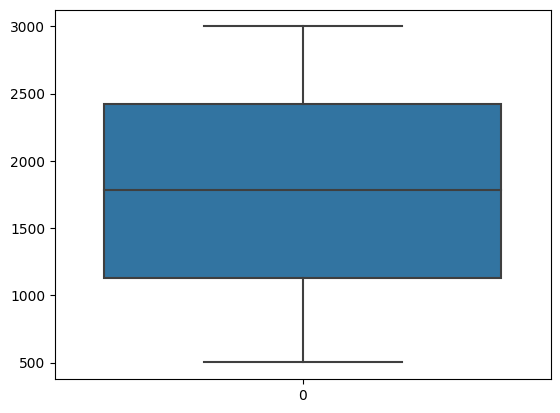

In [ ]:
#Verificar si hay valores atípicos
sns.boxplot(data=marketing_clean['gasto'])
#no hay valores atípicos

In [ ]:
#Conteo de duplicados
marketing_clean.duplicated().sum()

0

In [ ]:
#conteo de nulos
marketing_clean.isna().sum()

fecha           0
pais            0
id_campaña      0
canal         101
gasto           0
dtype: int64

In [ ]:
#revisar porcentaje de nulos
marketing_clean.isna().mean()

fecha         0.000000
pais          0.000000
id_campaña    0.000000
canal         0.062346
gasto         0.000000
dtype: float64

In [ ]:
#revisar si los nulos dependen de una categoría como país
marketing_clean['canal'].isna().groupby(marketing_clean['pais']).mean().sort_values(ascending=False)

pais
Argentina    0.062963
Mexico       0.062963
Colombia     0.061111
Name: canal, dtype: float64

In [ ]:
#revisar si los nulos en canal dependen de id_campaña
marketing_clean['canal'].isna().groupby(marketing_clean['id_campaña']).mean()

id_campaña
organic_Argentina        0.061111
organic_Colombia         0.061111
organic_Mexico           0.066667
paid_search_Argentina    0.061111
paid_search_Colombia     0.061111
paid_search_Mexico       0.061111
social_Argentina         0.066667
social_Colombia          0.061111
social_Mexico            0.061111
Name: canal, dtype: float64

In [ ]:
marketing_clean[marketing_clean['canal'].isna()]

,fecha,pais,id_campaña,canal,gasto
98,2025-01-11,Argentina,social_Argentina,NaN,849.70
99,2025-01-12,Mexico,organic_Mexico,NaN,2033.56
100,2025-01-12,Mexico,paid_search_Mexico,NaN,1260.65
101,2025-01-12,Mexico,social_Mexico,NaN,1660.90
102,2025-01-12,Colombia,organic_Colombia,NaN,1819.27
...,...,...,...,...,...
194,2025-01-22,Colombia,social_Colombia,NaN,772.46
195,2025-01-22,Argentina,organic_Argentina,NaN,1562.61
196,2025-01-22,Argentina,paid_search_Argentina,NaN,644.34
197,2025-01-22,Argentina,social_Argentina,NaN,2544.66


In [ ]:
#id_campaña contiene información de del canal, se usará para imputar los nulos

marketing_clean['canal'] = marketing_clean['canal'].fillna(
    marketing_clean['id_campaña'].apply(lambda x: '_'.join(str(x).split('_')[:-1]) if pd.notnull(x) else x)
)
marketing_clean.isna().sum()



fecha         0
pais          0
id_campaña    0
canal         0
gasto         0
dtype: int64

In [ ]:
marketing_clean.head()

,fecha,pais,id_campaña,canal,gasto
0,2025-01-01,Mexico,organic_Mexico,organic,2446.25
1,2025-01-01,Mexico,paid_search_Mexico,paid_search,2704.34
2,2025-01-01,Mexico,social_Mexico,social,2045.01
3,2025-01-01,Colombia,organic_Colombia,organic,2597.21
4,2025-01-01,Colombia,paid_search_Colombia,paid_search,1771.40


In [ ]:
marketing = marketing_clean

---
**📦 Exportación**: Una vez finalizada la limpieza, se exportan los datasets para utilizarlos en la última etapa del proyecto.

In [ ]:
# exportar datasets
orders.to_csv('orders_clean.csv', index=False)
catalog.to_csv('catalog_clean.csv', index=False)
marketing.to_csv('marketing_clean.csv', index=False)

---

## 🔹 Paso 2: Analizar si el negocio es rentable

### 2.1 Cálculo de KPIs principales

**🎯 Objetivo:** Calcular los indicadores clave del negocio para evaluar ingresos, costos y rentabilidad.

Se usan los 3 datasets (`orders`, `catalog`, `marketing_spend`):

**📊 Parte 1: Rentabilidad del negocio**
- ¿Cuál es el ingreso total (revenue)?
- ¿Cuál es el costo total?
- ¿Cuánto se ha invertido en marketing?
- ¿El negocio es rentable? (calcular profit)  

---

**📈 Parte 2: Comportamiento de ventas**
- ¿Cuál es el ticket promedio por orden?
- ¿Cuál es la cantidad promedio de productos por orden?
- ¿Cuál es el producto más vendido?
- ¿Cuánto se ha gastado en marketing por canal?

In [ ]:

# ingreso total
ingreso_total = orders['monto_total'].sum()
#unir tablas catalog y orders
df_merged = pd.merge(orders, catalog[['nombre_producto','costo_unitario']], on='nombre_producto', how='left', validate='m:1')
#costo total
costo_total= (df_merged['costo_unitario']* df_merged['cantidad']).sum()
#unir tablas catalog y orders
df_merged = pd.merge(orders, catalog[['nombre_producto','costo_unitario']], on='nombre_producto', how='left', validate='m:1')
#costo total
costo_total= (df_merged['costo_unitario']* df_merged['cantidad']).sum()
print('el ingreso total es de:', ingreso_total )
print()
print('el costo_total es de:' , costo_total)

el ingreso total es de: 9627993.650000002

el costo_total es de: 3834482.61


<function matplotlib.pyplot.show(close=None, block=None)>

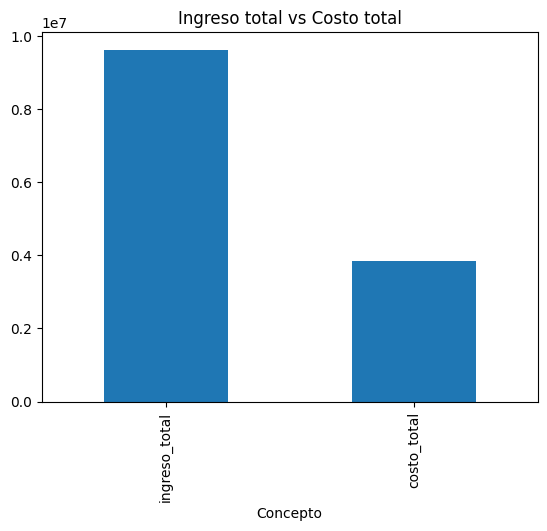

In [ ]:
comparacion = pd.Series([ingreso_total,costo_total], index=['ingreso_total', 'costo_total'])
comparacion.plot(kind='bar')
plt.title('Ingreso total vs Costo total')
plt.xlabel('Concepto')
plt.show

In [ ]:
# gasto marketing
gasto_marketing = marketing['gasto'].sum()
print(f'el gasto de marketing fue de :${gasto_marketing}')

el gasto de marketing fue de :$2871843.53


In [ ]:
#rentabilidad
ganancia = ingreso_total-costo_total
rentabilidad = (ganancia / ingreso_total)*100
print(f'la rentabilidad es de: {rentabilidad}')


la rentabilidad es de: 60.173606782551225


In [ ]:
#ticket promedio
ticket_promedio = ingreso_total / orders['id_pedido'].nunique()
print(f'El ticket promedio es de: ${ticket_promedio}')

El ticket promedio es de: $385.9534053555681


In [ ]:
#producto mas vendido
orders.groupby('nombre_producto')['cantidad'].sum().sort_values(ascending=False)


nombre_producto
Vacuum-Pro-Black        6284.0
Blender-XL-Red          6279.0
Jacket-Winter-M         6256.0
Sneakers-Urban-42       6172.0
Laptop-Gaming-16GB      4218.0
Tablet-Standard-64GB    4153.0
Phone-Pro-128GB         4140.0
Desconocido               45.0
Name: cantidad, dtype: float64

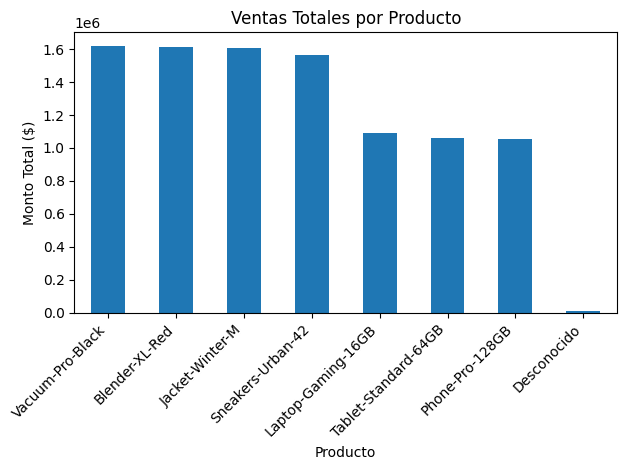

In [ ]:
#Producto mas vendido
df_ventas_producto = df_merged.groupby('nombre_producto')['monto_total'].sum().reset_index()
df_ventas_producto = df_ventas_producto.sort_values(by='monto_total', ascending=False)
df_ventas_producto.plot(x='nombre_producto', y='monto_total', kind='bar', legend=False)

plt.title('Ventas Totales por Producto')
plt.xlabel('Producto')
plt.ylabel('Monto Total ($)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
#Vacuum-Pro_Black lidera ligeramente las ventas de producto

In [ ]:


#cantidad promedio de productos por orden
orders_clean['cantidad'].mean()



1.5051310831395814

In [ ]:
#gasto de marketing por canal
marketing_clean.groupby('canal')['gasto'].sum().sort_values(ascending=False)

canal
social         976818.37
organic        972650.96
paid_search    922374.20
Name: gasto, dtype: float64

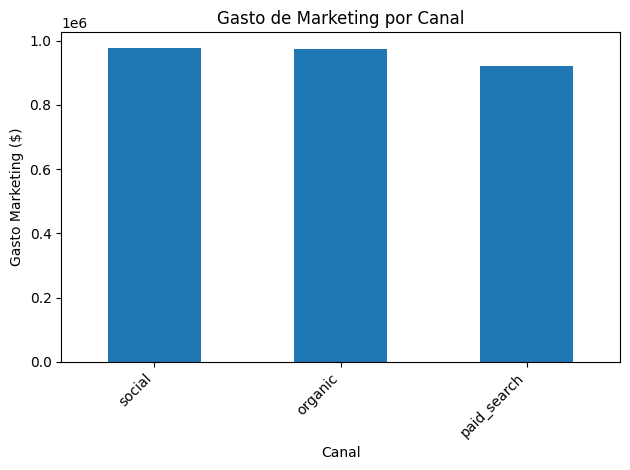

In [ ]:
gasto_por_canal = marketing.groupby('canal')['gasto'].sum().reset_index()

gasto_por_canal = gasto_por_canal.sort_values(by='gasto', ascending=False)

gasto_por_canal.plot(x='canal', y='gasto', kind='bar', legend=False)

plt.title('Gasto de Marketing por Canal')
plt.xlabel('Canal')
plt.ylabel('Gasto Marketing ($)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

---

## 🔹 Paso 3: Entender dónde se pierden los usuarios (funnel de conversión)

**🎯 Objetivo:** Analizar el comportamiento de los usuarios para identificar en qué etapa del proceso se pierden.


⚙️**Conexión a la base de datos**:  
Se ejecuta la línea de configuración para conectar con la base de datos y aplicar consultas SQL en la tabla **events**.

---

**📊 Parte 1: Construcción del funnel**
- ¿Cuántos usuarios llegan a cada etapa del funnel?  
- Se calcula el número de usuarios únicos por `nombre_evento`  
- Se ordenan los eventos según el flujo del usuario  

---

**📉 Parte 2: Análisis de conversión**
- Se calcula la tasa de conversión entre cada paso del funnel  
- Se identifica en qué etapa se pierde la mayor cantidad de usuarios  
- ¿Cuál es la tasa de conversión final?
---

In [ ]:
import pandas as pd
from sqlalchemy import create_engine

# ======================
# Conexión (NO modificar)
# ======================
db_config = {
    'user': 'practicum_student',
    'pwd': 'QnmDH8Sc2TQLvy2G3Vvh7',
    'host': 'yp-trainers-practicum.cluster-czs0gxyx2d8w.us-east-1.rds.amazonaws.com',
    'port': 5432,
    'db': 'data-analyst-production-db-en'
}

connection_string = 'postgresql://{}:{}@{}:{}/{}'.format(
    db_config['user'],
    db_config['pwd'],
    db_config['host'],
    db_config['port'],
    db_config['db']
)

engine = create_engine(connection_string, connect_args={'sslmode':'require'})

In [ ]:
# Explorar tabla events
# =========================
query_events = '''
SELECT *
FROM events;
'''
events = pd.read_sql(query_events, con=engine)
events.head()

,id_usuario,id_sesion,nombre_evento,timestamp_evento,pais,dispositivo,fuente_referencia,categoria_producto
0,user_6772,6a97f2af-32ae-4186-8c92-04025be1a27b,first_visit,2025-05-17,Colombia,desktop,organic,Moda
1,user_5883,369b767c-1c33-4b2f-a652-c7c0ef92cfc9,add_to_cart,2025-02-23,Mexico,mobile,social,Hogar
2,user_5946,60039041-e78b-474c-87b3-c0b7e9c30708,add_payment_info,2025-05-15,Colombia,desktop,social,Electronica
3,user_827,18252a64-f389-4ef7-9e58-dadad4a3491e,purchase,2025-03-31,Mexico,mobile,social,Moda
4,user_2361,221b364e-cdc5-4668-b698-18d5ba849a67,first_visit,2025-01-22,Argentina,desktop,paid_search,Electronica


In [ ]:
events['nombre_evento'].value_counts()

first_visit         29957
add_to_cart         24157
select_item         23887
begin_checkout      17971
add_payment_info    12018
purchase            12010
Name: nombre_evento, dtype: int64

In [ ]:
# PARTE 1: Totales del funnel
# ======================

query_totals = '''
WITH cte_first_visit AS(
SELECT DISTINCT id_usuario
FROM events
WHERE nombre_evento = 'first_visit'
),
cte_select_item AS(
SELECT DISTINCT id_usuario
FROM events
WHERE nombre_evento = 'select_item'
),
cte_add_to_cart AS(
SELECT DISTINCT id_usuario
FROM events
WHERE nombre_evento = 'add_to_cart'
),
cte_begin_checkout AS(
SELECT DISTINCT id_usuario
FROM events
WHERE nombre_evento = 'begin_checkout'
),
cte_add_payment_info AS(
SELECT DISTINCT id_usuario
FROM events
WHERE nombre_evento = 'add_payment_info'
),
cte_purchase AS (
SELECT DISTINCT id_usuario
FROM events
WHERE nombre_evento = 'purchase'
)
SELECT
(SELECT COUNT(*)FROM cte_first_visit) AS first_visit_users,
(SELECT COUNT(*)FROM cte_select_item) AS select_item_users,
(SELECT COUNT(*)FROM cte_add_to_cart) AS add_to_cart_users,
(SELECT COUNT(*)FROM cte_begin_checkout) AS begin_checkout_users,
(SELECT COUNT(*)FROM cte_add_payment_info) AS add_payment_info_users,
(SELECT COUNT(*)FROM cte_purchase) AS purchase_users;
'''

totals = pd.read_sql(query_totals, con=engine)
totals

,first_visit_users,select_item_users,add_to_cart_users,begin_checkout_users,add_payment_info_users,purchase_users
0,7796,7582,7634,7208,6250,6240


In [ ]:
#CANTIDAD DE USUARIOS QUE HICIERON UNA COMPRA SIN SELECCIONAR ITEM
query_saltar_pasos = '''

SELECT COUNT(*) AS total_usuarios
FROM (
    SELECT DISTINCT id_usuario
    FROM events
    WHERE nombre_evento = 'purchase'
      AND id_usuario NOT IN (
          SELECT DISTINCT id_usuario
          FROM events
          WHERE nombre_evento = 'select_item'
      )
) AS usuarios_sin_select;

'''
usuarios_saltar_pasos = pd.read_sql(query_saltar_pasos, con=engine)
usuarios_saltar_pasos


,total_usuarios
0,320


In [ ]:
#Algunos usuarios tienen el comportamiento de saltarse la etapa de seleccionar item, se dejaran en el funnel por si representan un comportamiento real de los usuarios

In [ ]:
# PARTE 2: Conversiones
# ======================

query_conversion = '''
WITH cte_first_visit AS (
    SELECT DISTINCT id_usuario FROM events WHERE nombre_evento = 'first_visit'
),
cte_select_item AS (
    SELECT DISTINCT id_usuario FROM events WHERE nombre_evento = 'select_item'
),
cte_add_to_cart AS (
    SELECT DISTINCT id_usuario FROM events WHERE nombre_evento = 'add_to_cart'
),
cte_begin_checkout AS (
    SELECT DISTINCT id_usuario FROM events WHERE nombre_evento = 'begin_checkout'
),
cte_add_payment_info AS (
    SELECT DISTINCT id_usuario FROM events WHERE nombre_evento = 'add_payment_info'
),
cte_purchase AS (
    SELECT DISTINCT id_usuario FROM events WHERE nombre_evento = 'purchase'
)
SELECT
    (SELECT COUNT(*) FROM cte_first_visit) AS first_visit_users,
    (SELECT COUNT(*) FROM cte_select_item) AS select_item_users,
    (SELECT COUNT(*) FROM cte_add_to_cart) AS add_to_cart_users,
    (SELECT COUNT(*) FROM cte_begin_checkout) AS begin_checkout_users,
    (SELECT COUNT(*) FROM cte_add_payment_info) AS add_payment_info_users,
    (SELECT COUNT(*) FROM cte_purchase) AS purchase_users,

    ROUND((SELECT COUNT(*) FROM cte_select_item)      * 100.0 / NULLIF((SELECT COUNT(*) FROM cte_first_visit),0), 2) AS conv_select_item,
    ROUND((SELECT COUNT(*) FROM cte_add_to_cart)      * 100.0 / NULLIF((SELECT COUNT(*) FROM cte_first_visit),0), 2) AS conv_add_to_cart,
    ROUND((SELECT COUNT(*) FROM cte_begin_checkout)   * 100.0 / NULLIF((SELECT COUNT(*) FROM cte_first_visit),0), 2) AS conv_begin_checkout,
    ROUND((SELECT COUNT(*) FROM cte_add_payment_info) * 100.0 / NULLIF((SELECT COUNT(*) FROM cte_first_visit),0), 2) AS conv_add_payment_info,
    ROUND((SELECT COUNT(*) FROM cte_purchase)         * 100.0 / NULLIF((SELECT COUNT(*) FROM cte_first_visit),0), 2) AS conv_final;
'''

conversion = pd.read_sql(query_conversion, con=engine)
conversion

,first_visit_users,select_item_users,add_to_cart_users,begin_checkout_users,add_payment_info_users,purchase_users,conv_select_item,conv_add_to_cart,conv_begin_checkout,conv_add_payment_info,conv_final
0,7796,7582,7634,7208,6250,6240,97.26,97.92,92.46,80.17,80.04


---

## 🔹 Paso 4: Evaluar si los usuarios regresan (retención por cohortes)

**🎯 Objetivo:** Analizar la retención de usuarios para entender si regresan después de registrarse.

**Tablas**

- `users`
- `user_activity`

---
1. Se identifica la cohorte de cada usuario según el **mes de registro**.


2. Se calcula la retención semanal: cuántos usuarios **se mantienen activos** en cada semana desde su registro.
   - `retenido_w1`: usuarios activos en la semana 1  
   - `retenido_w2`: usuarios activos en la semana 2  
   - `retenido_w3`: usuarios activos en la semana 3  


3. Se calcula el porcentaje de retención para cada semana, dividiendo los usuarios retenidos entre los clientes iniciales de la cohorte:  
   - `semana_1`: porcentaje de usuarios retenidos en la semana 1  
   - `semana_2`: porcentaje de usuarios retenidos en la semana 2  
   - `semana_3`: porcentaje de usuarios retenidos en la semana 3  

Se revisa que la columna de fecha esté en formato correcto (`DATE`).  
Se realiza la conversión usando: `CAST(fecha_registro AS DATE)`

In [ ]:
# Explorar tabla users
# =========================
query_users = '''
SELECT *
FROM users;
'''
users = pd.read_sql(query_users, con=engine)
users.head(3)

,id_usuario,fecha_registro,país,dispositivo,tipo_plan
0,user_0,2025-01-29,Mexico,mobile,free
1,user_1,2025-01-07,Mexico,mobile,free
2,user_2,2025-03-12,Argentina,mobile,free


In [ ]:
# Explorar tabla user_activity
# =========================
query_user_activity = '''
SELECT *
FROM user_activity
'''
user_activity = pd.read_sql(query_user_activity, con=engine)
user_activity.head(3)

,id_usuario,fecha_actividad,dias_despues_registro,activo
0,user_0,2025-02-05,7,0
1,user_0,2025-02-12,14,1
2,user_0,2025-02-19,21,1


In [ ]:
# Retención por cohortes
# ======================

query_cohort_retention_final = '''
WITH cohorte AS (
    SELECT
        u.id_usuario,
        DATE_TRUNC('month', MIN(u.fecha_registro::DATE)) AS cohorte_mensual
    FROM users AS u
    GROUP BY u.id_usuario
),

actividad AS (
    SELECT
        c.id_usuario,
        c.cohorte_mensual,
        ua.dias_despues_registro,
        ua.activo
    FROM cohorte AS c
    LEFT JOIN user_activity AS ua
        ON c.id_usuario = ua.id_usuario
),

retencion AS (
    SELECT
        a.cohorte_mensual,

        COUNT(DISTINCT a.id_usuario) AS clientes_iniciales,

        COUNT(DISTINCT CASE
            WHEN a.dias_despues_registro BETWEEN 1 AND 7
                 AND a.activo = 1
            THEN a.id_usuario
        END) AS retenido_w1,

        COUNT(DISTINCT CASE
            WHEN a.dias_despues_registro BETWEEN 8 AND 14
                 AND a.activo = 1
            THEN a.id_usuario
        END) AS retenido_w2,

        COUNT(DISTINCT CASE
            WHEN a.dias_despues_registro BETWEEN 15 AND 21
                 AND a.activo = 1
            THEN a.id_usuario
        END) AS retenido_w3

    FROM actividad AS a
    GROUP BY a.cohorte_mensual
)

SELECT
    TO_CHAR(r.cohorte_mensual, 'YYYY-MM') AS cohorte,
    r.clientes_iniciales,

    ROUND(r.retenido_w1::NUMERIC / NULLIF(r.clientes_iniciales, 0) * 100, 2) AS semana_1,
    ROUND(r.retenido_w2::NUMERIC / NULLIF(r.clientes_iniciales, 0) * 100, 2) AS semana_2,
    ROUND(r.retenido_w3::NUMERIC / NULLIF(r.clientes_iniciales, 0) * 100, 2) AS semana_3

FROM retencion AS r
ORDER BY r.cohorte_mensual;


'''

# Ejecutar la consulta
cohorte_final = pd.read_sql(query_cohort_retention_final, con=engine)
cohorte_final

,cohorte,clientes_iniciales,semana_1,semana_2,semana_3
0,2025-01,1627,42.84,41.06,40.32
1,2025-02,1444,42.31,42.17,43.98
2,2025-03,1636,41.38,43.09,42.18
3,2025-04,1606,42.34,43.40,41.28
4,2025-05,1687,41.20,40.07,41.85


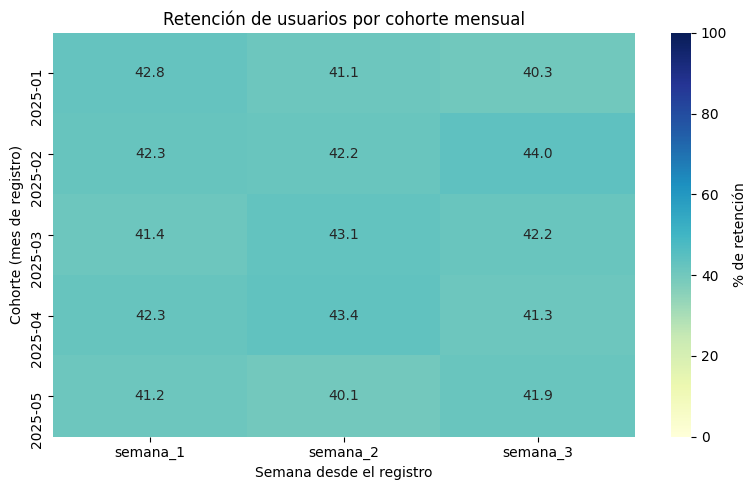

In [ ]:
matriz = cohorte_final.set_index('cohorte')[['semana_1', 'semana_2', 'semana_3']]

plt.figure(figsize=(8, 5))
sns.heatmap(matriz, annot=True, fmt='.1f', cmap='YlGnBu', vmin=0, vmax=100,
            cbar_kws={'label': '% de retención'})
plt.title('Retención de usuarios por cohorte mensual')
plt.xlabel('Semana desde el registro')
plt.ylabel('Cohorte (mes de registro)')
plt.tight_layout()
plt.show()

---

## 🔹 Paso 5: Validar si los cambios generan impacto (test estadístico)

🎯 **Objetivo:** Evaluar si la modificación en la UI del checkout impacta la **tasa de conversión de compra**.

---

1. **Analizar el dataset** `experiment_checkout_ui.csv` para identificar la métrica principal **conversion**.
   - La métrica **conversion** es 1 si el usuario completó la compra, 0 si no.    
2. **Plantear la hipótesis estadística**     
3. **Aplicar el test estadístico adecuado**
4. **Interpretar el resultado**  

---
Hipótesis estadística
   - **H₀ (Hipótesis nula): La modificación del UI no afecta la conversión**
   - **H₁ (Hipótesis alternativa):La modificación del UI afecta la conversión**
   
**Test estadístico:** z test  
**Nivel de significancia alpha:** 0.05

In [ ]:
# tu código aquí
experiment = pd.read_csv('https://practicum-content.s3.amazonaws.com/datasets/experiment_checkout_ui.csv')
experiment.head()



,id_usuario,variante,convirtio,dispositivo,pais,duracion_sesion,timestamp
0,exp_user_0,tratamiento,0,mobile,Argentina,114.41,2025-03-28
1,exp_user_1,tratamiento,0,desktop,Mexico,170.03,2025-01-15
2,exp_user_2,control,1,mobile,Colombia,140.21,2025-03-18
3,exp_user_3,tratamiento,0,mobile,Colombia,151.45,2025-06-03
4,exp_user_4,tratamiento,0,desktop,Mexico,299.96,2025-01-12


In [ ]:
conversion = experiment.groupby('variante')['convirtio'].sum()
# Total de usuarios por página
total= experiment.groupby('variante')['convirtio'].count()
print("Usuarios convertidos por página:\n", conversion)
print("\nTotal de usuarios por página:\n", total)



Usuarios convertidos por página:
 variante
control        779
tratamiento    820
Name: convirtio, dtype: int64

Total de usuarios por página:
 variante
control        4965
tratamiento    5035
Name: convirtio, dtype: int64


In [ ]:
exitos= [conversion['tratamiento'], conversion['control']]
observaciones= [total['tratamiento'], total['control']]


In [ ]:
z_stat, p_value= proportions_ztest (exitos, observaciones)


# Visualizar resultados
print(f"Estadístico : {z_stat}")
print(f"Valor p: {p_value}")

alpha = 0.05
if p_value < alpha:
    print('Rechazamos la hipótesis nula, hay evidencia de una diferencia.')
else:
    print('No rechazamos la hipótesis nula, no hay evidencia de una diferencia.')


Estadístico : 0.8132782986429474
Valor p: 0.41605851639119995
No rechazamos la hipótesis nula, no hay evidencia de una diferencia.


---

## Reporte ejecutivo

# 1. Rentabilidad del negocio
Hallazgo: el negocio es rentable, pero hay que distinguir dos niveles. El margen bruto (60.2%) muestra que el producto en sí deja buen margen sobre su costo. Sin embargo, una vez restado el gasto de marketing, el profit neto real es del 30.3%. Es la diferencia entre "el producto es rentable" y "el negocio, de punta a punta, es rentable"; ambas cosas son ciertas aquí, pero en distinta magnitud.

Hallazgo adicional: los productos de Moda y Hogar (Vacuum-Pro-Black, Blender-XL-Red, Jacket-Winter-M, Sneakers-Urban-42) casi duplican en unidades vendidas a los de Electrónica (Laptop, Tablet, Phone), pero el margen entre ellos varía muchísimo más que el ingreso: Sneakers-Urban-42 y Jacket-Winter-M generan un ingreso similar (~$520K cada uno), pero Sneakers convierte cerca del 93% de ese ingreso en profit, mientras que Jacket-Winter-M solo el ~27%, por tener un costo unitario mucho más alto.

Insight accionable: revisar el margen por producto, no solo el ingreso. Un producto puede parecer "estrella" por volumen de ventas y aun así ser el que menos aporta a la ganancia. Vale la pena evaluar si se puede renegociar el costo de Jacket-Winter-M con el proveedor, o si conviene reposicionar su precio.

El gasto de marketing está bien distribuido entre canales (social $976,818, organic $972,651, paid_search $922,374), sin que ninguno concentre el gasto de forma desproporcionada.

# 2 Funnel de conversión

Hallazgo: la conversión final de principio a fin es del 80.04%, un número saludable. La mayor caída del funnel ocurre entre begin_checkout y add_payment_info (12.29 puntos porcentuales), muy por encima de cualquier otra transición.

Hallazgo adicional: 320 usuarios llegaron a comprar sin pasar por el evento select_item, lo que explica por qué add_to_cart (97.92%) tiene una conversión ligeramente mayor que select_item (97.26%). El funnel real de los usuarios no es estrictamente lineal: existe una ruta alterna de compra.

Insight accionable: el checkout (begin_checkout → add_payment_info) es el punto de mayor fricción del proceso completo. Antes de invertir en atraer más tráfico, conviene investigar esa etapa específica (¿el formulario de pago es muy largo? ¿fallan los métodos de pago? ¿hay costos ocultos que se revelan ahí?), porque resolverla probablemente tenga más impacto en ingresos que cualquier otra mejora del funnel.

# 3 Prueba A/B: nuevo diseño de checkout
Hallazgo: con un valor p de 0.416, no se rechaza la hipótesis nula. No hay evidencia estadística de que el nuevo diseño del checkout cambie la conversión.

Hallazgo adicional (poder estadístico): con ~5,000 usuarios por grupo, el experimento solo puede detectar de forma confiable diferencias de 2 puntos porcentuales o más. El lift observado (0.60 pp) está por debajo de ese umbral, así que "no hay evidencia de diferencia" no es lo mismo que "no hay diferencia": el experimento, tal como está diseñado, no tiene la sensibilidad necesaria para detectar un efecto de ese tamaño.

Insight accionable: antes de descartar el nuevo diseño de checkout, se recomienda extender el experimento para acumular más usuarios (idealmente hasta poder detectar un efecto de 0.5-1 pp), en vez de concluir que "no funciona" con la evidencia actual. Dado que el problema más grande identificado en el funnel es justo la caída en el checkout, vale la pena que el siguiente experimento se enfoque específicamente en esa etapa.


# Conclusión

RappiPlus es un negocio rentable (30.3% de profit neto), con un funnel de conversión sólido (80% de principio a fin) y una retención estable, aunque sin señales de mejora reciente. El mayor punto de oportunidad identificado en todo el análisis es consistente entre dos secciones distintas: el checkout, tanto en el funnel (mayor caída de todo el proceso) como en la prueba A/B (la hipótesis que se está probando, aunque sin resultado concluyente todavía). Las prioridades sugeridas, en orden de impacto potencial, son: (1) investigar a fondo la fricción en begin_checkout → add_payment_info, (2) revisar el margen por producto individual, no solo el ingreso, y (3) ampliar la muestra del experimento A/B antes de tomar una decisión sobre el nuevo diseño.